<a href="https://colab.research.google.com/github/gorbunovr98-glitch/data-analysis/blob/main/%D0%94_%D0%97%C2%AB%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5_%D1%80%D1%8F%D0%B4%D1%8B%2C_%D0%BE%D0%B1%D1%89%D0%B0%D1%8F_%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import os

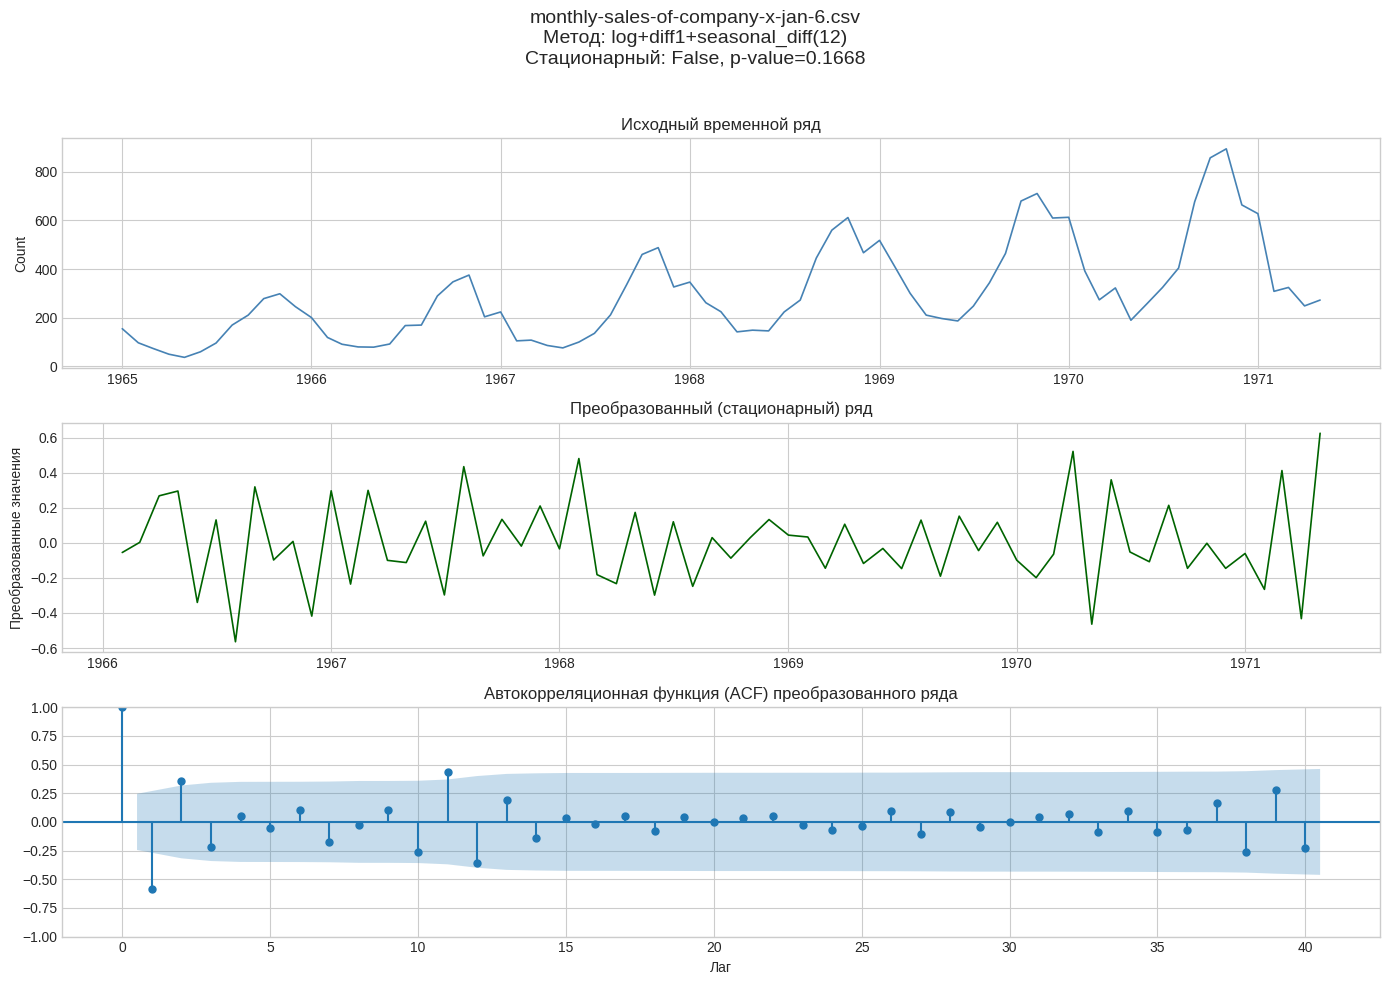

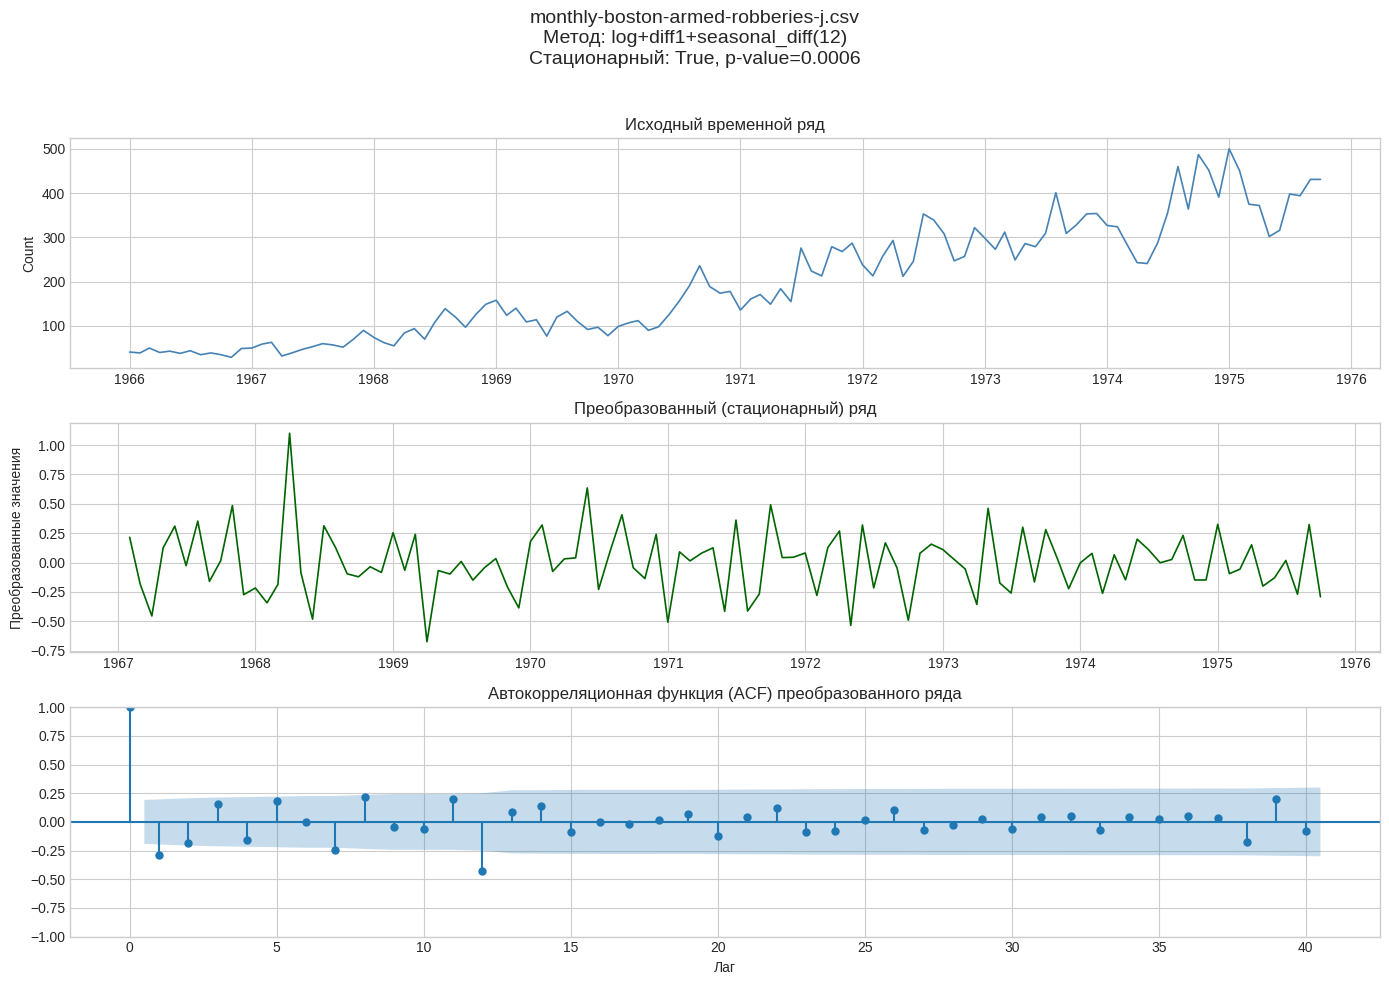

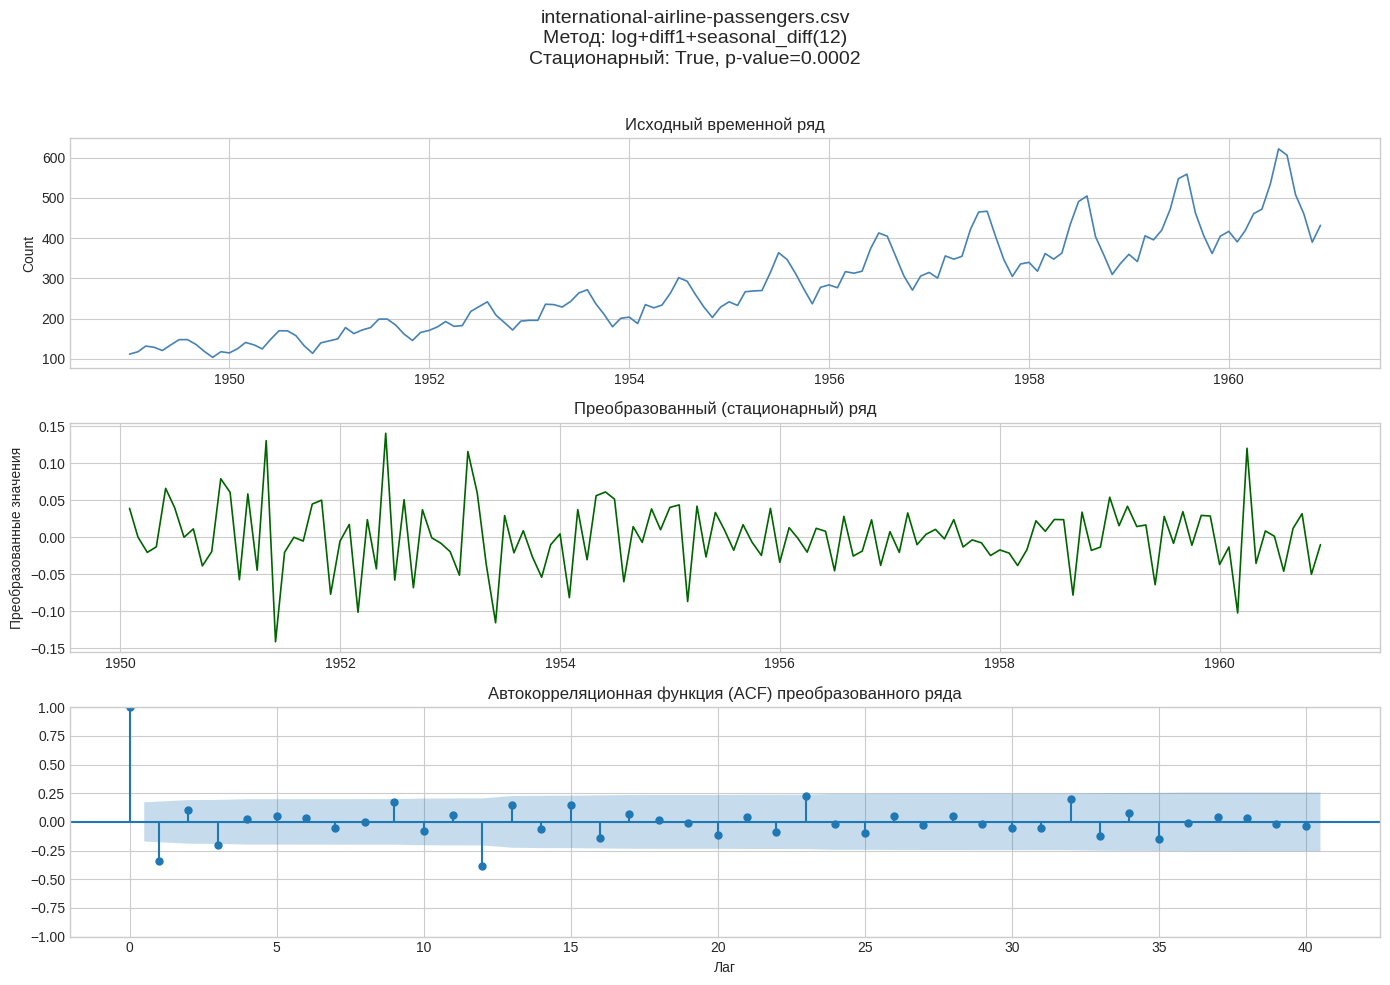

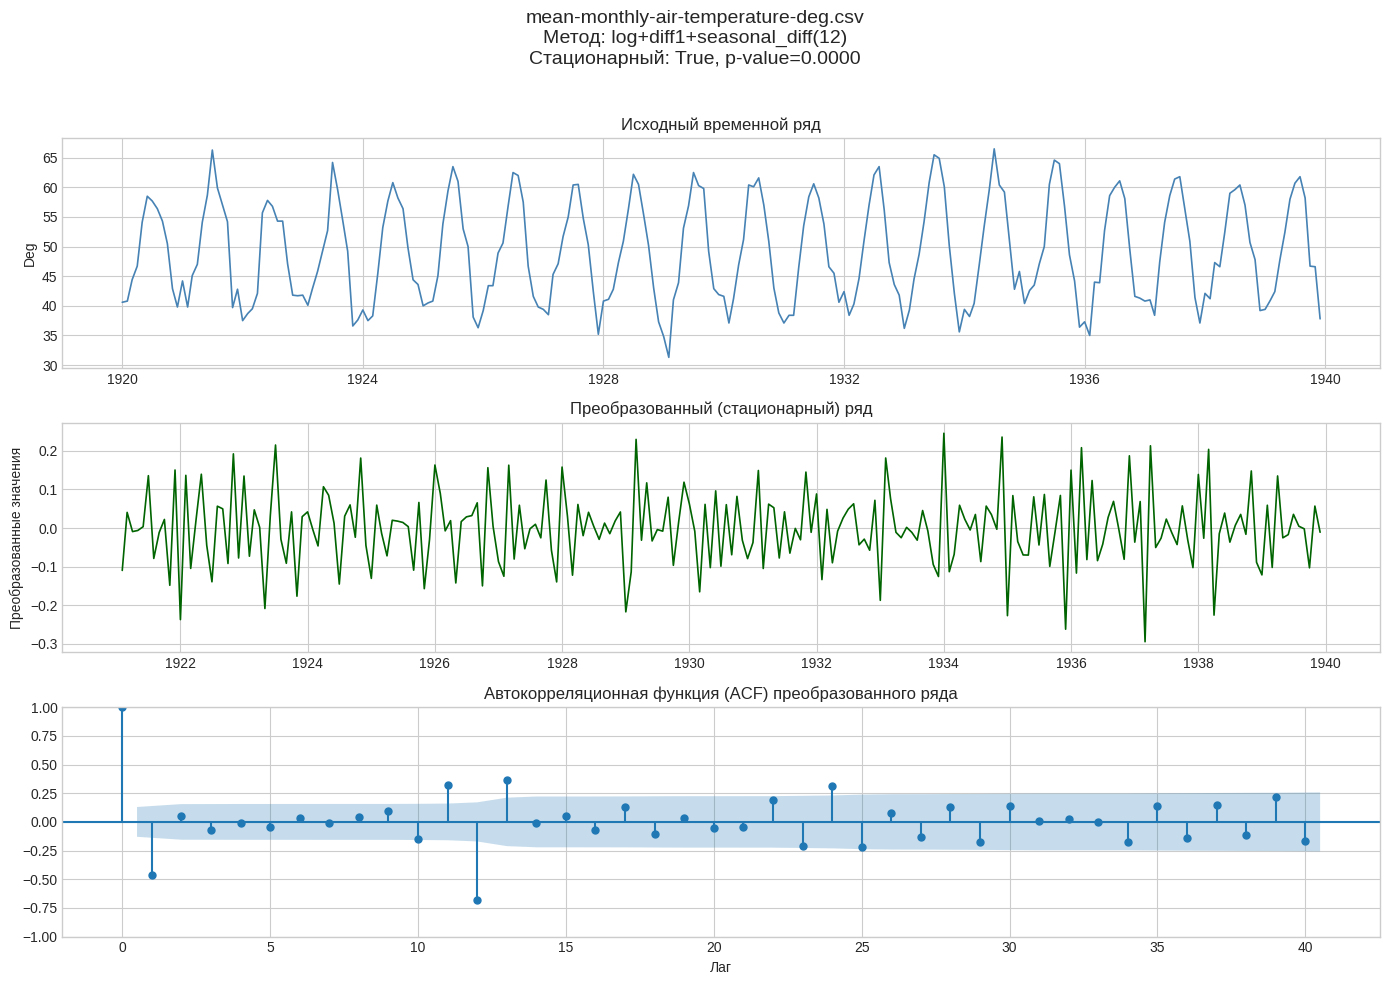

Не удалось определить колонки в weekly-closings-of-the-dowjones-.csv. Проверьте вручную.


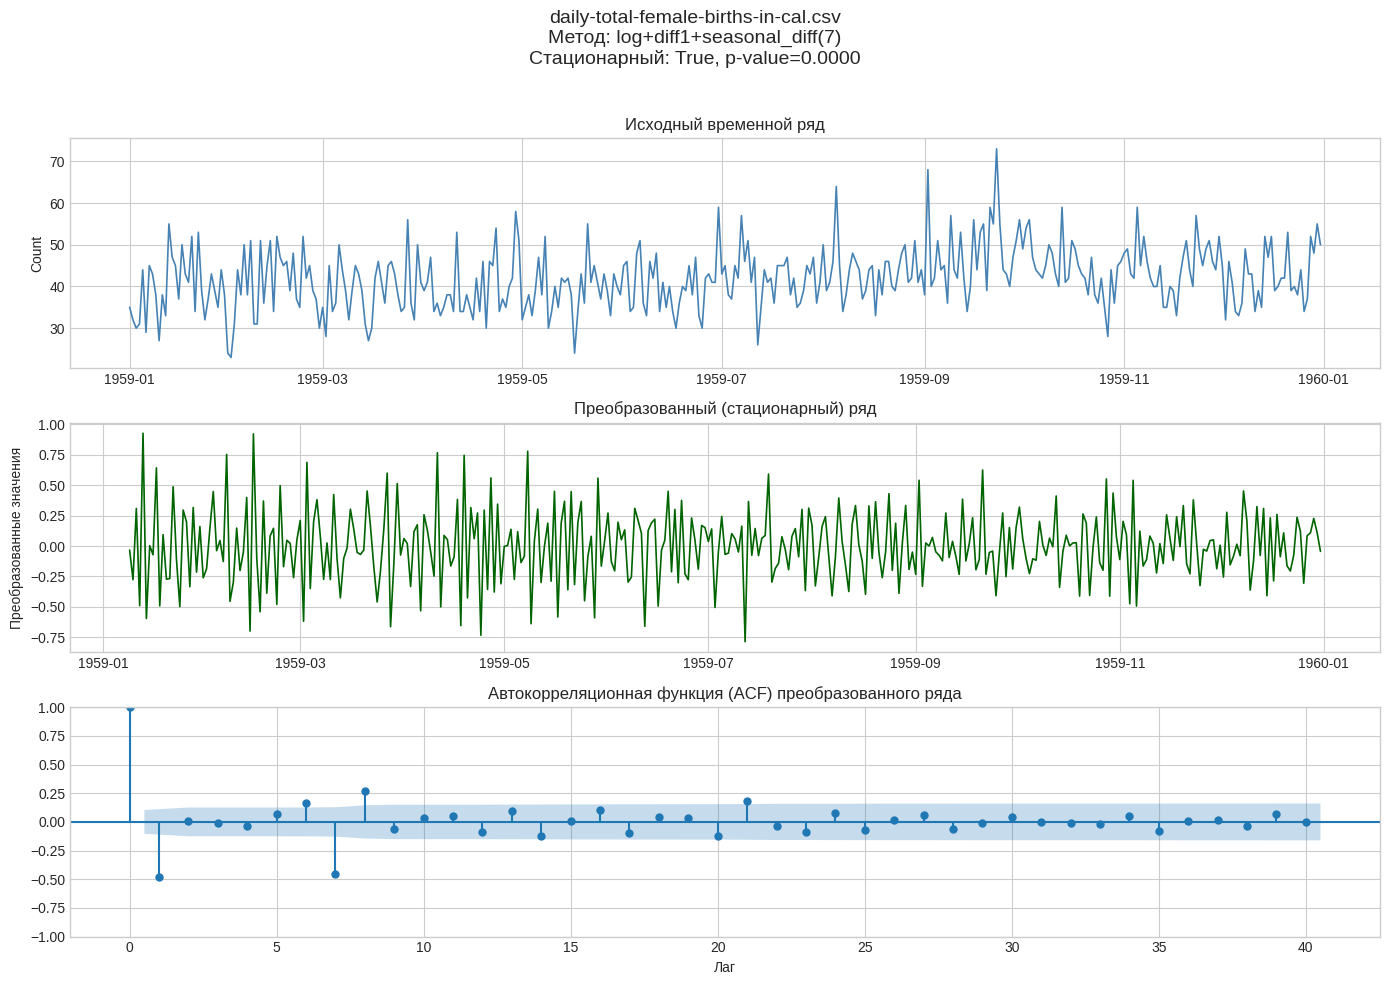

In [7]:
# Список файлов
files = [
    "monthly-sales-of-company-x-jan-6.csv",
    "monthly-boston-armed-robberies-j.csv",
    "international-airline-passengers.csv",
    "mean-monthly-air-temperature-deg.csv",
    "weekly-closings-of-the-dowjones-.csv",
    "daily-total-female-births-in-cal.csv"
]

def make_stationary(series, freq=None):
    """
    Возвращает преобразованный ряд и описание применённого метода.
    """
    if (series > 0).all():
        s = np.log(series)
        method = "log"
    else:
        s = series.copy()
        method = "none"

    s_diff = s.diff().dropna()
    method += "+diff1"

    if freq == "M":
        seasonal_period = 12
        s_diff = s_diff.diff(seasonal_period).dropna()
        method += f"+seasonal_diff({seasonal_period})"
    elif freq == "D":
        seasonal_period = 7
        s_diff = s_diff.diff(seasonal_period).dropna()
        method += f"+seasonal_diff({seasonal_period})"

    return s_diff, method

def test_stationarity(series):
    result = adfuller(series.dropna())
    return result[1] < 0.05, result[1]

plt.style.use("seaborn-v0_8-whitegrid")

for fname in files:
    fpath = fname  # текущий каталог

    df = pd.read_csv(fpath)

    # Автоопределение колонок
    date_col = None
    value_col = None
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]) or col.lower() in ["date", "time", "month", "year"]:
            date_col = col
        elif pd.api.types.is_numeric_dtype(df[col]):
            value_col = col

    if date_col is None or value_col is None:
        print(f"Не удалось определить колонки в {fname}. Проверьте вручную.")
        continue

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    series = df[value_col]

    # Определение частоты
    diffs = np.diff(df.index.astype(np.int64))
    freq = None
    if len(diffs) > 0:
        median_days = np.median(diffs) / (24 * 3600 * 1e9)
        if abs(median_days - 30) < 5:
            freq = "M"
        elif abs(median_days - 7) < 2:
            freq = "W"
        elif abs(median_days - 1) < 0.5:
            freq = "D"

    stationary_series, method = make_stationary(series, freq)
    is_stat, pval = test_stationarity(stationary_series)

    # Построение графиков
    fig, axs = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"{fname}\nМетод: {method}\nСтационарный: {is_stat}, p-value={pval:.4f}", fontsize=14)

    # 1. Исходный ряд
    axs[0].plot(series.index, series.values, linewidth=1.2, color="steelblue")
    axs[0].set_title("Исходный временной ряд")
    axs[0].set_ylabel(value_col)

    # 2. Стационарный ряд
    axs[1].plot(stationary_series.index, stationary_series.values, linewidth=1.2, color="darkgreen")
    axs[1].set_title("Преобразованный (стационарный) ряд")
    axs[1].set_ylabel("Преобразованные значения")

    # 3. ACF преобразованного ряда
    plot_acf(stationary_series, lags=min(40, len(stationary_series)-1), ax=axs[2], alpha=0.05)
    axs[2].set_title("Автокорреляционная функция (ACF) преобразованного ряда")
    axs[2].set_xlabel("Лаг")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
